# WiDS 2026 EDA - Wildfire Survival Analysis

Exploratory data analysis for the WiDS 2026 Datathon: Predicting Time-to-Threat for Evacuation Zones.

## Section 1: Data Loading & Basic Info

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = 'D:/wids/'
train = pd.read_csv(DATA_DIR + 'train.csv')
test = pd.read_csv(DATA_DIR + 'test.csv')
meta = pd.read_csv(DATA_DIR + 'metaData.csv')

print('train shape:', train.shape)
print('test  shape:', test.shape)
print('meta  shape:', meta.shape)

train shape: (221, 37)
test  shape: (95, 35)
meta  shape: (37, 6)


In [5]:
print('=== dtypes ===')
print(train.dtypes)
print()
print('=== Missing values ===')
missing = train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values')

=== dtypes ===
event_id                          int64
num_perimeters_0_5h               int64
dt_first_last_0_5h              float64
low_temporal_resolution_0_5h      int64
area_first_ha                   float64
area_growth_abs_0_5h            float64
area_growth_rel_0_5h            float64
area_growth_rate_ha_per_h       float64
log1p_area_first                float64
log1p_growth                    float64
log_area_ratio_0_5h             float64
relative_growth_0_5h            float64
radial_growth_m                 float64
radial_growth_rate_m_per_h      float64
centroid_displacement_m         float64
centroid_speed_m_per_h          float64
spread_bearing_deg              float64
spread_bearing_sin              float64
spread_bearing_cos              float64
dist_min_ci_0_5h                float64
dist_std_ci_0_5h                float64
dist_change_ci_0_5h             float64
dist_slope_ci_0_5h              float64
closing_speed_m_per_h           float64
closing_speed_abs_m_per_h

In [6]:
print('=== Target: event distribution ===')
event_counts = train['event'].value_counts().sort_index()
print(event_counts)
print(f'\nHit rate: {event_counts[1] / len(train):.1%}')
print(f'Censored: {event_counts[0]} ({event_counts[0]/len(train):.1%})')
print(f'Hit:      {event_counts[1]} ({event_counts[1]/len(train):.1%})')

=== Target: event distribution ===
event
0    152
1     69
Name: count, dtype: int64

Hit rate: 31.2%
Censored: 152 (68.8%)
Hit:      69 (31.2%)


## Section 2: Target Variable Analysis

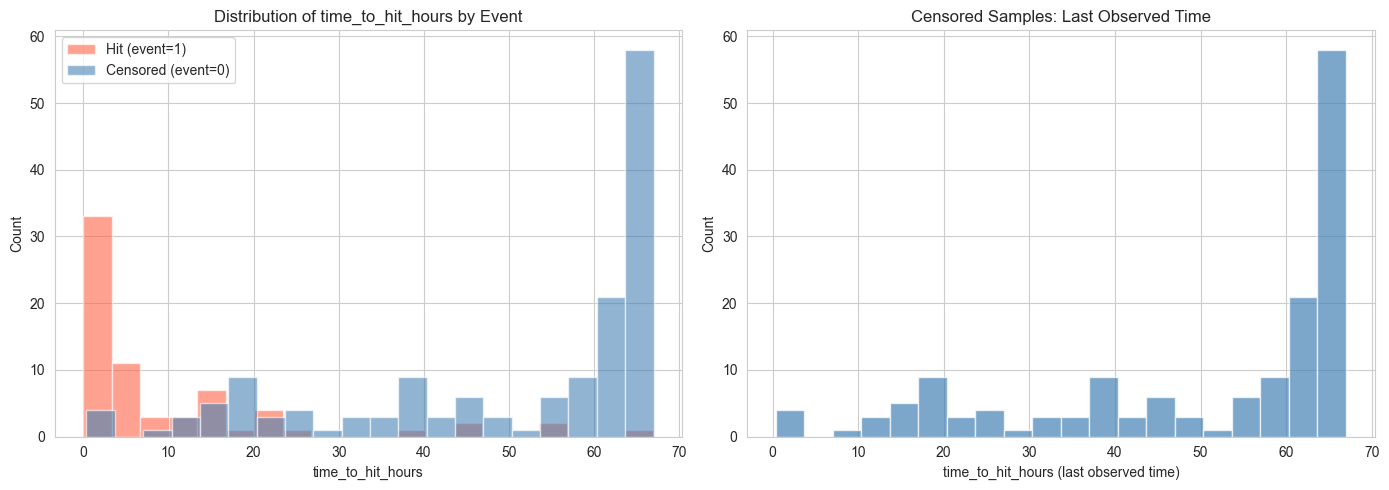

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: time_to_hit_hours by event
for ev, color, label in [(1, 'tomato', 'Hit (event=1)'), (0, 'steelblue', 'Censored (event=0)')]:
    subset = train[train['event'] == ev]['time_to_hit_hours']
    axes[0].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_xlabel('time_to_hit_hours')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of time_to_hit_hours by Event')
axes[0].legend()

# Right: censored samples only
censored = train[train['event'] == 0]['time_to_hit_hours']
axes[1].hist(censored, bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('time_to_hit_hours (last observed time)')
axes[1].set_ylabel('Count')
axes[1].set_title('Censored Samples: Last Observed Time')

plt.tight_layout()
plt.show()

In [8]:
# Horizon eligible sample statistics
# Rules from competition: for each horizon H:
#   label=1: event==1 AND time_to_hit_hours <= H
#   label=0: event==0 AND time_to_hit_hours > H  (observed past H without hit)
#   excluded: event==0 AND time_to_hit_hours <= H (censored before H, unknown outcome)

horizons = [12, 24, 48, 72]
rows = []
for H in horizons:
    hits = train[(train['event'] == 1) & (train['time_to_hit_hours'] <= H)]
    survives = train[(train['event'] == 0) & (train['time_to_hit_hours'] > H)]
    excluded = train[(train['event'] == 0) & (train['time_to_hit_hours'] <= H)]
    eligible = len(hits) + len(survives)
    pos_rate = len(hits) / eligible if eligible > 0 else 0
    rows.append({
        'horizon': f'{H}h',
        'label=1 (hit)': len(hits),
        'label=0 (survive)': len(survives),
        'excluded (censored)': len(excluded),
        'eligible_total': eligible,
        'positive_rate': f'{pos_rate:.1%}'
    })

horizon_df = pd.DataFrame(rows)
print('=== Horizon Eligible Sample Statistics ===')
print(horizon_df.to_string(index=False))

=== Horizon Eligible Sample Statistics ===
horizon  label=1 (hit)  label=0 (survive)  excluded (censored)  eligible_total positive_rate
    12h             49                146                    6             195         25.1%
    24h             63                127                   25             190         33.2%
    48h             66                 97                   55             163         40.5%
    72h             69                  0                  152              69        100.0%


## Section 3: Feature Overview

In [9]:
# Group features by category from metadata
feature_cols = [c for c in train.columns if c not in ['event_id', 'time_to_hit_hours', 'event']]
meta_feat = meta[meta['type'] == 'feature'][['column', 'category']].copy()
categories = meta_feat.groupby('category')['column'].apply(list).to_dict()

for cat, cols in categories.items():
    valid_cols = [c for c in cols if c in train.columns]
    if not valid_cols:
        continue
    print(f'\n=== {cat} ({len(valid_cols)} features) ===')
    desc = train[valid_cols].describe().T[['mean', 'std', 'min', 'max']]
    desc['zero_pct'] = (train[valid_cols] == 0).mean().values
    print(desc.round(4).to_string())


=== centroid_kinematics (5 features) ===
                            mean       std     min        max  zero_pct
centroid_displacement_m  44.2779  218.7596  0.0000  2045.3331    0.8869
centroid_speed_m_per_h   11.9535   58.9405  0.0000   595.0587    0.8869
spread_bearing_deg       13.7719   46.7033  0.0000   290.1393    0.8869
spread_bearing_sin        0.0537    0.2852 -0.9997     0.9977    0.8869
spread_bearing_cos        0.8904    0.3519 -0.9749     1.0000    0.0000

=== directionality (4 features) ===
                         mean      std       min       max  zero_pct
alignment_cos         -0.0050   0.3719   -1.0000    0.9946    0.7240
alignment_abs          0.1727   0.3292    0.0000    1.0000    0.7240
cross_track_component  1.6172  37.7892 -213.4117  277.1104    0.8869
along_track_speed      0.5517  46.7606 -526.5972  383.0992    0.8869

=== distance (9 features) ===
                                  mean          std        min          max  zero_pct
dist_min_ci_0_5h           

In [10]:
# low_temporal_resolution impact analysis
low_res = train['low_temporal_resolution_0_5h']
print(f'low_temporal_resolution=1: {low_res.sum()}/{len(train)} ({low_res.mean():.1%})')
print()

# Compare feature means: low_res=1 vs low_res=0
growth_cols = [c for c in feature_cols if c != 'low_temporal_resolution_0_5h']
g1 = train[low_res == 1][growth_cols].mean()
g0 = train[low_res == 0][growth_cols].mean()
comparison = pd.DataFrame({'low_res=0': g0, 'low_res=1': g1})
comparison['ratio'] = (comparison['low_res=1'] / comparison['low_res=0']).replace([np.inf, -np.inf], np.nan)
print('=== Feature means: low_res=0 vs low_res=1 ===')
print(comparison.round(4).to_string())

low_temporal_resolution=1: 161/221 (72.9%)

=== Feature means: low_res=0 vs low_res=1 ===
                             low_res=0    low_res=1   ratio
num_perimeters_0_5h             4.9000       1.0062  0.2053
dt_first_last_0_5h              3.6035       0.0021  0.0006
area_first_ha                 147.8568     794.7620  5.3752
area_growth_abs_0_5h           96.9910       0.0000  0.0000
area_growth_rel_0_5h            0.6590       0.0000  0.0000
area_growth_rate_ha_per_h      22.7156       0.0000  0.0000
log1p_area_first                3.7245       5.0406  1.3534
log1p_growth                    1.4341       0.0000  0.0000
log_area_ratio_0_5h             0.2410       0.0000  0.0000
relative_growth_0_5h            0.6590       0.0000  0.0000
radial_growth_m               108.3989       0.0000  0.0000
radial_growth_rate_m_per_h     28.6207       0.0000  0.0000
centroid_displacement_m       163.0902       0.0000  0.0000
centroid_speed_m_per_h         44.0288       0.0000  0.0000
spread_bea

## Section 4: Key Features vs Target

C:\Users\55093\AppData\Local\Temp\ipykernel_149312\100157534.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='event', y=feat, data=train, ax=ax, palette=['steelblue', 'tomato'])
C:\Users\55093\AppData\Local\Temp\ipykernel_149312\100157534.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='event', y=feat, data=train, ax=ax, palette=['steelblue', 'tomato'])
C:\Users\55093\AppData\Local\Temp\ipykernel_149312\100157534.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='event', y=feat, data=train, ax=ax, palette=['steelblue', 'tomat

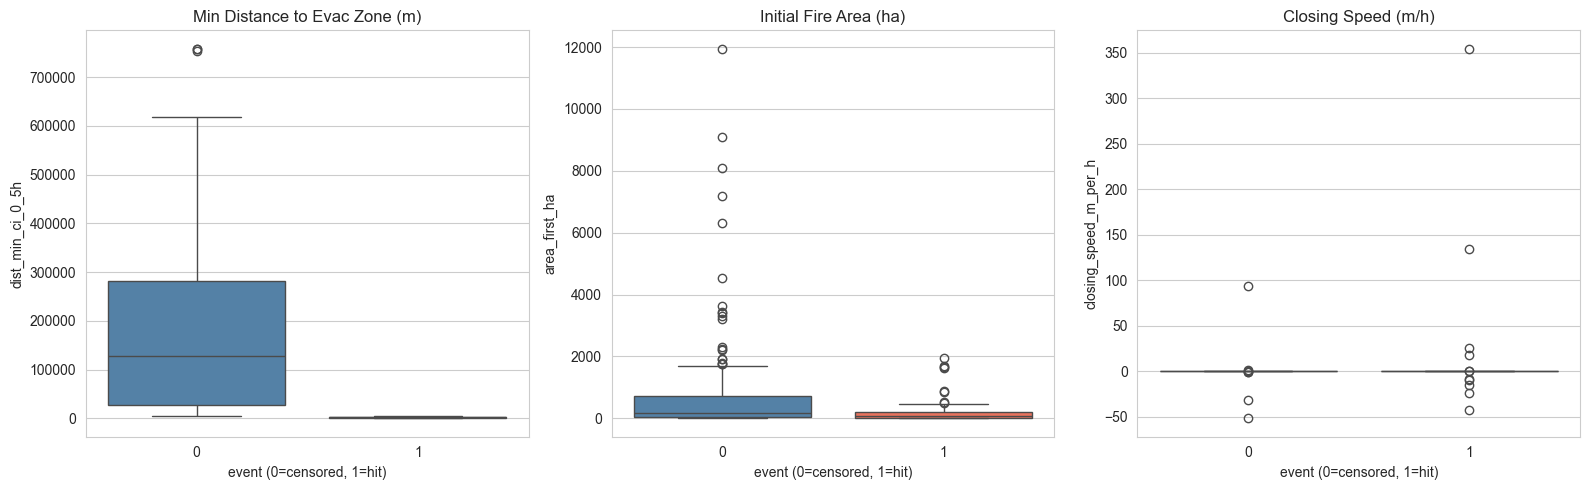

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

key_features = ['dist_min_ci_0_5h', 'area_first_ha', 'closing_speed_m_per_h']
titles = ['Min Distance to Evac Zone (m)', 'Initial Fire Area (ha)', 'Closing Speed (m/h)']

for ax, feat, title in zip(axes, key_features, titles):
    sns.boxplot(x='event', y=feat, data=train, ax=ax, palette=['steelblue', 'tomato'])
    ax.set_title(title)
    ax.set_xlabel('event (0=censored, 1=hit)')

plt.tight_layout()
plt.show()

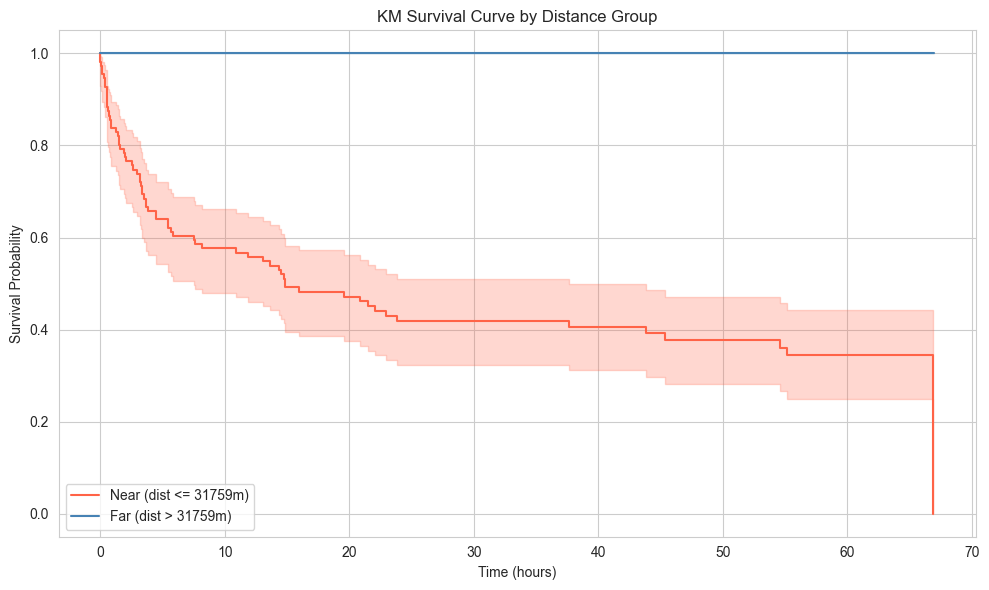

In [12]:
# Kaplan-Meier survival curve grouped by dist_min_ci_0_5h median
median_dist = train['dist_min_ci_0_5h'].median()
train['dist_group'] = np.where(train['dist_min_ci_0_5h'] <= median_dist, 'Near', 'Far')
    
try:
    from lifelines import KaplanMeierFitter
    kmf = KaplanMeierFitter()
    fig, ax = plt.subplots(figsize=(10, 6))
    for grp, color in [('Near', 'tomato'), ('Far', 'steelblue')]:
        mask = train['dist_group'] == grp
        kmf.fit(train.loc[mask, 'time_to_hit_hours'],
                event_observed=train.loc[mask, 'event'],
                label=f'{grp} (dist {"<=" if grp=="Near" else ">"} {median_dist:.0f}m)')
        kmf.plot_survival_function(ax=ax, color=color)
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Survival Probability')
    ax.set_title('KM Survival Curve by Distance Group')
    plt.tight_layout()
    plt.show()

except ImportError:
    # Fallback: manual KM using step function
    fig, ax = plt.subplots(figsize=(10, 6))
    for grp, color in [('Near', 'tomato'), ('Far', 'steelblue')]:
        subset = train[train['dist_group'] == grp].sort_values('time_to_hit_hours')
        times = subset['time_to_hit_hours'].values
        events = subset['event'].values
        n = len(times)
        surv = 1.0
        t_plot, s_plot = [0], [1.0]
        for i in range(n):
            at_risk = n - i
            if events[i] == 1:
                surv *= (1 - 1 / at_risk)
            t_plot.append(times[i])
            s_plot.append(surv)
        label = f'{grp} (dist {"<=" if grp=="Near" else ">"} {median_dist:.0f}m)'
        ax.step(t_plot, s_plot, where='post', color=color, label=label, linewidth=2)
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Survival Probability')
    ax.set_title('KM Survival Curve by Distance Group (manual)')
    ax.legend()
    plt.tight_layout()
    plt.show()

train.drop(columns=['dist_group'], inplace=True)

## Section 5: Feature Correlation

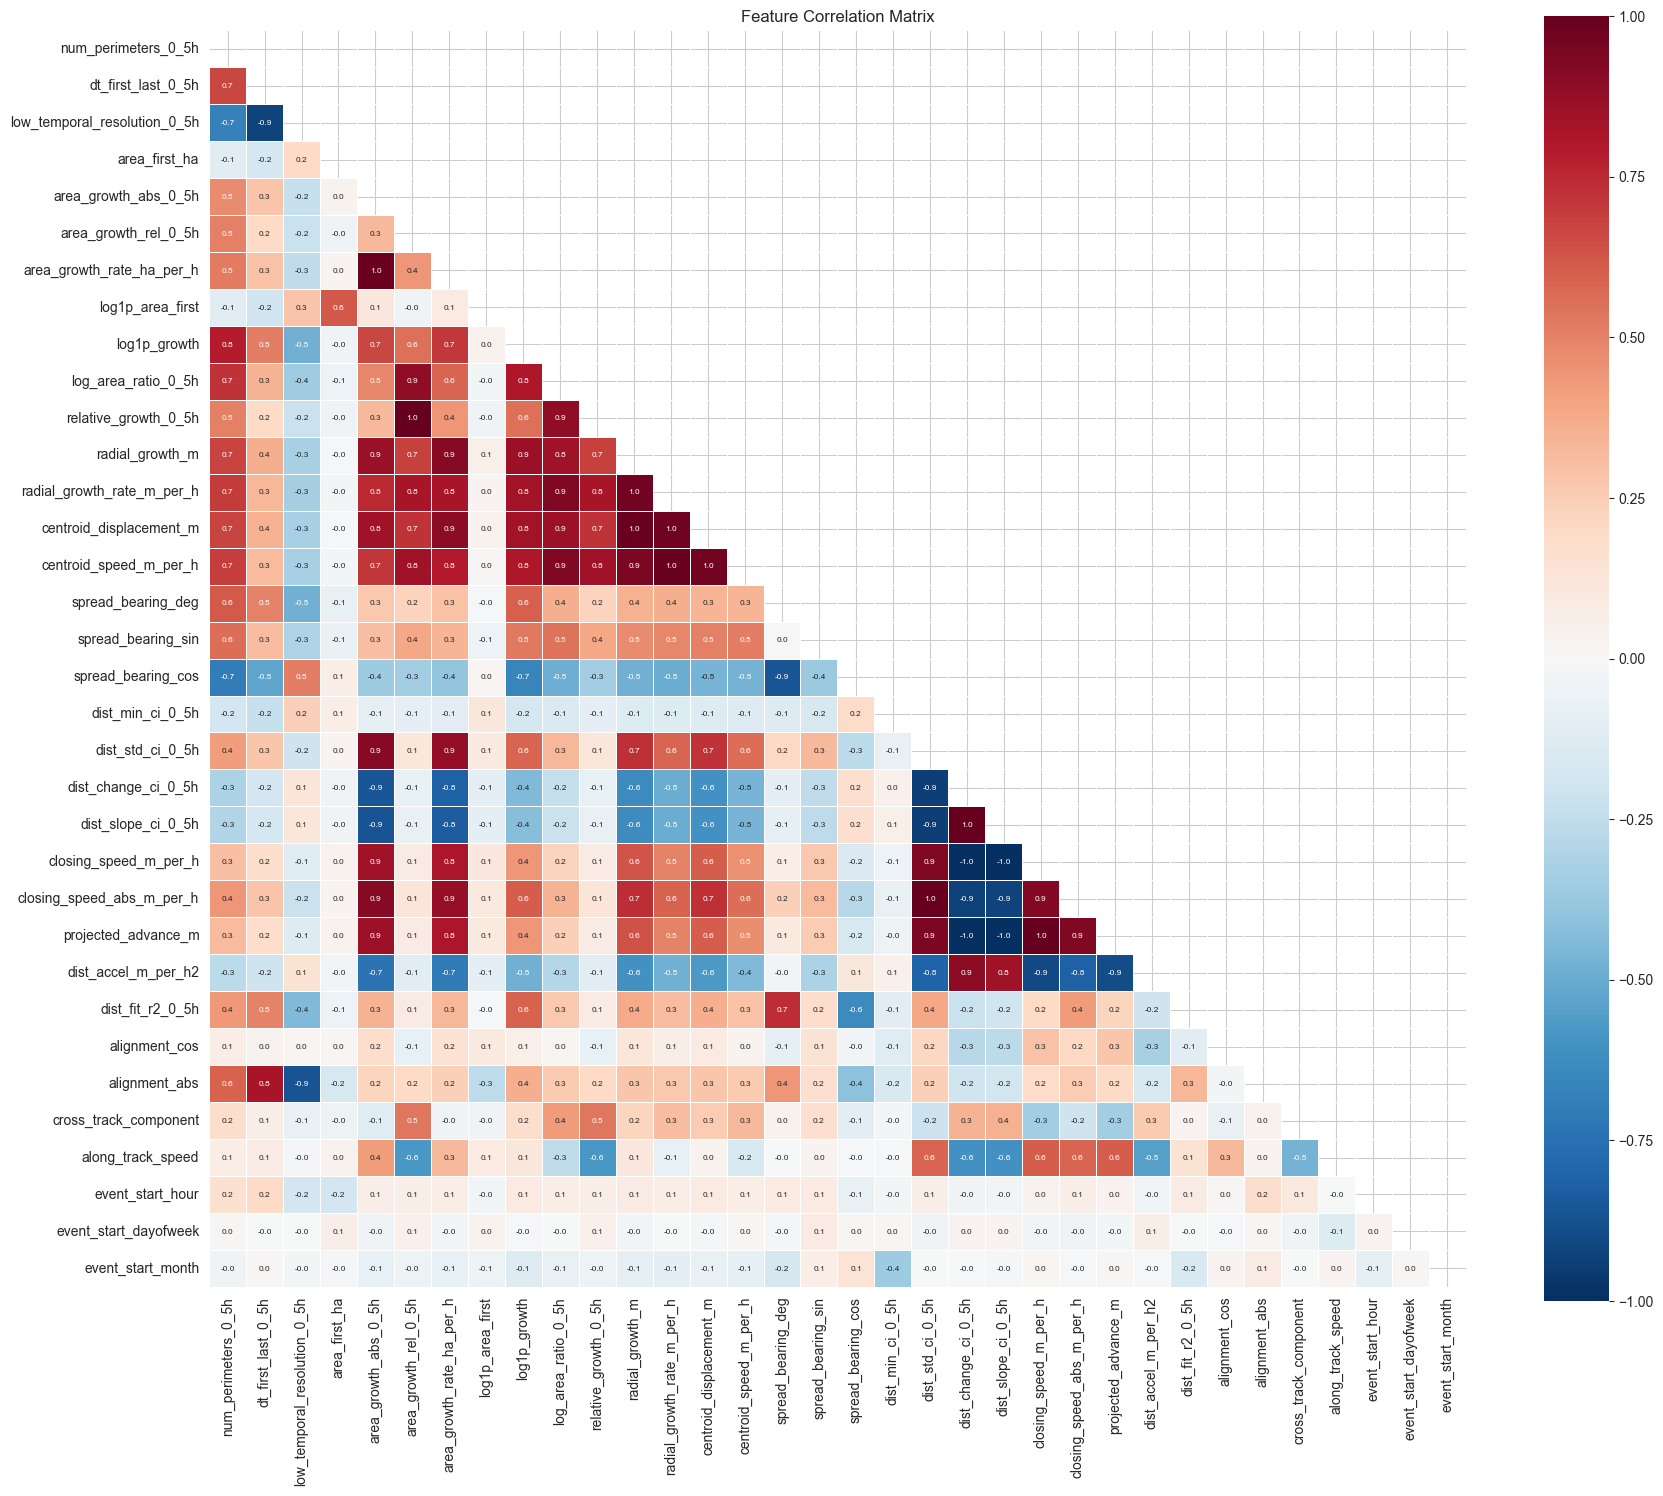

In [13]:
# Correlation heatmap for all 34 features
corr = train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, fmt='.1f',
            annot=True, annot_kws={'size': 6})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

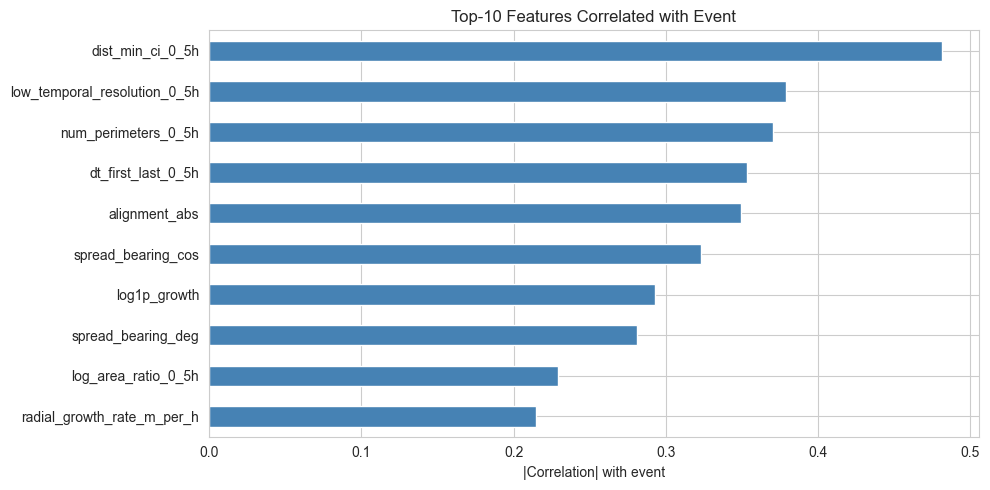

Top-10 features by |corr| with event:
  dist_min_ci_0_5h                         -0.4814
  low_temporal_resolution_0_5h             -0.3791
  num_perimeters_0_5h                      +0.3705
  dt_first_last_0_5h                       +0.3530
  alignment_abs                            +0.3491
  spread_bearing_cos                       -0.3232
  log1p_growth                             +0.2927
  spread_bearing_deg                       +0.2810
  log_area_ratio_0_5h                      +0.2293
  radial_growth_rate_m_per_h               +0.2150


In [14]:
# Top-10 features correlated with event
event_corr = train[feature_cols + ['event']].corr()['event'].drop('event').abs().sort_values(ascending=False)
top10 = event_corr.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top10.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('|Correlation| with event')
ax.set_title('Top-10 Features Correlated with Event')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top-10 features by |corr| with event:')
for feat, val in top10.items():
    sign = '+' if train[feature_cols + ['event']].corr()['event'][feat] > 0 else '-'
    print(f'  {feat:40s} {sign}{val:.4f}')

In [15]:
# High collinearity pairs (|corr| > 0.9)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'feature_1': corr.columns[i],
                'feature_2': corr.columns[j],
                'correlation': round(corr.iloc[i, j], 4)
            })

if high_corr_pairs:
    hc_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)
    print(f'=== High Collinearity Pairs (|corr| > 0.9): {len(hc_df)} pairs ===')
    print(hc_df.to_string(index=False))
else:
    print('No feature pairs with |corr| > 0.9')

=== High Collinearity Pairs (|corr| > 0.9): 29 pairs ===
                 feature_1                    feature_2  correlation
      area_growth_rel_0_5h         relative_growth_0_5h       1.0000
       dist_change_ci_0_5h          projected_advance_m      -1.0000
       dist_change_ci_0_5h        closing_speed_m_per_h      -0.9982
     closing_speed_m_per_h          projected_advance_m       0.9982
          dist_std_ci_0_5h    closing_speed_abs_m_per_h       0.9969
        dist_slope_ci_0_5h          projected_advance_m      -0.9931
       dist_change_ci_0_5h           dist_slope_ci_0_5h       0.9931
        dist_slope_ci_0_5h        closing_speed_m_per_h      -0.9931
      area_growth_abs_0_5h    area_growth_rate_ha_per_h       0.9913
           radial_growth_m      centroid_displacement_m       0.9891
radial_growth_rate_m_per_h       centroid_speed_m_per_h       0.9890
radial_growth_rate_m_per_h      centroid_displacement_m       0.9692
           radial_growth_m   radial_growth_rat

## Section 6: Train vs Test Distribution

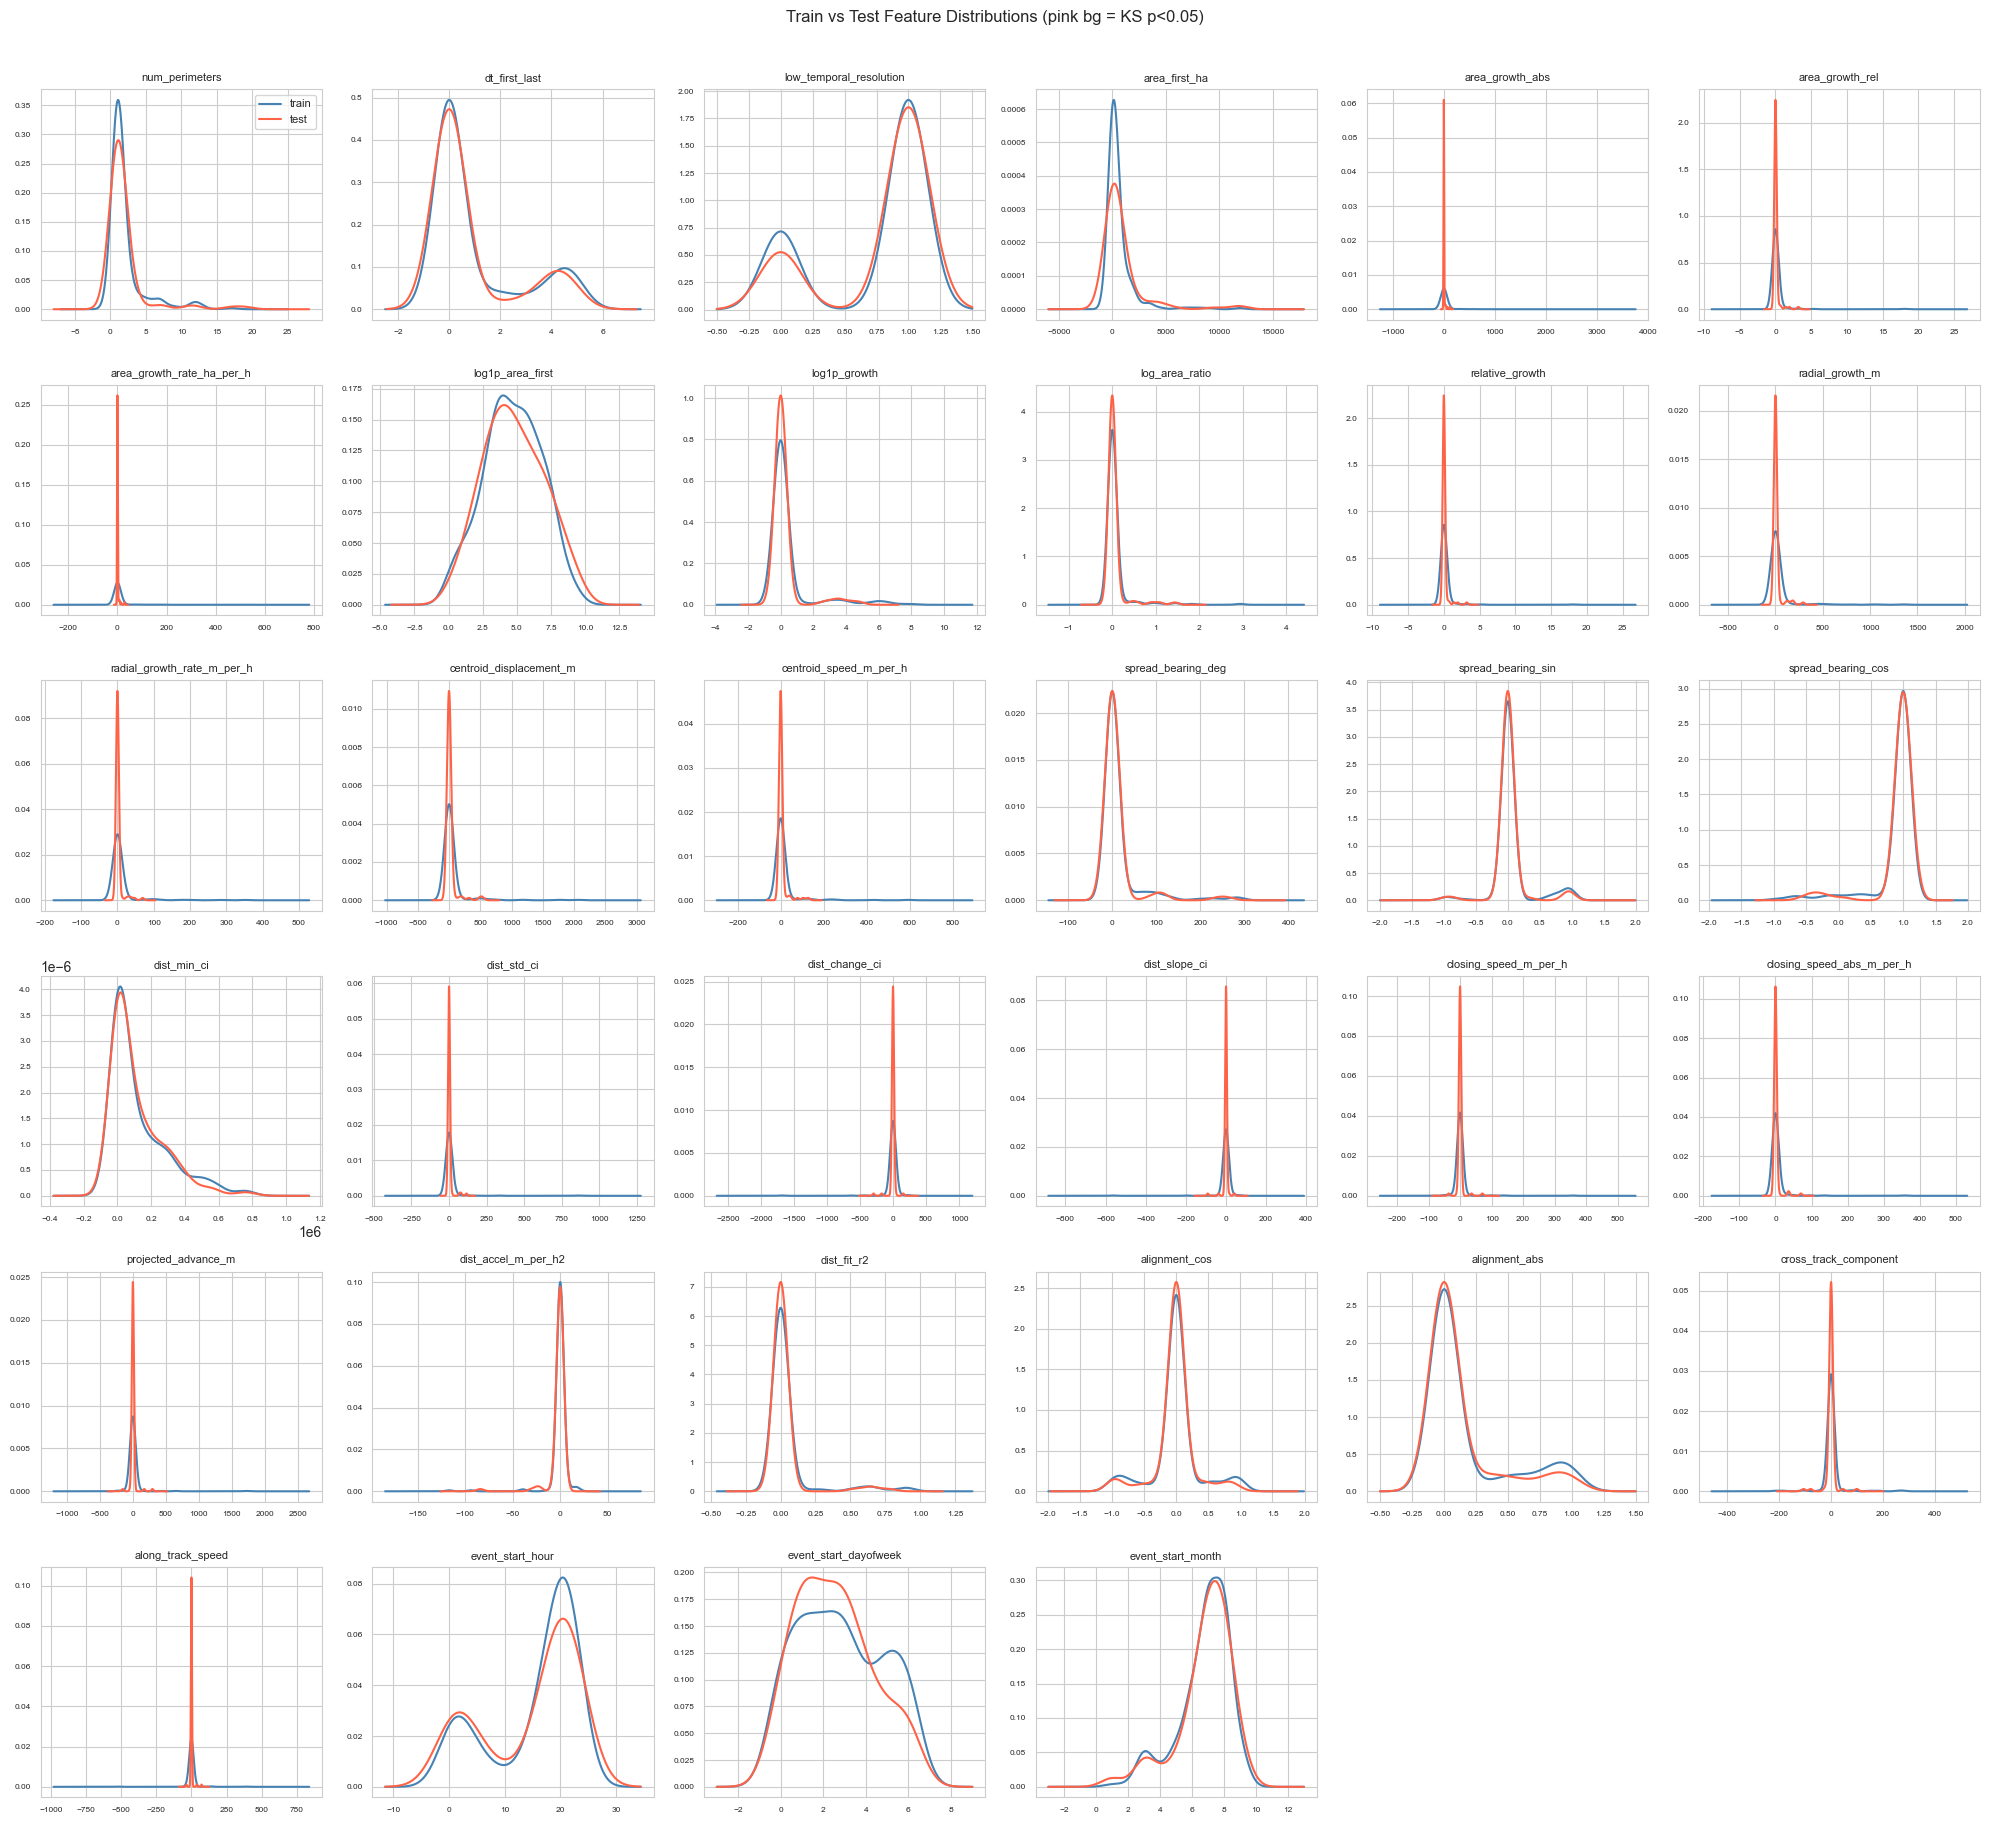

In [16]:
# Train vs Test distribution comparison with KS test
n_features = len(feature_cols)
n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

ks_results = []
for i, feat in enumerate(feature_cols):
    ax = axes[i]
    train_vals = train[feat].dropna()
    test_vals = test[feat].dropna()

    # KDE plot
    if train_vals.std() > 0:
        train_vals.plot(kind='kde', ax=ax, color='steelblue', label='train', linewidth=1.5)
    if test_vals.std() > 0:
        test_vals.plot(kind='kde', ax=ax, color='tomato', label='test', linewidth=1.5)

    # KS statistic
    ks_stat, ks_p = stats.ks_2samp(train_vals, test_vals)
    ks_results.append({'feature': feat, 'ks_stat': ks_stat, 'ks_pvalue': ks_p})

    ax.set_title(feat.replace('_0_5h', ''), fontsize=8)
    ax.tick_params(labelsize=6)
    ax.set_ylabel('')
    if ks_p < 0.05:
        ax.set_facecolor('#fff3f3')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8)
plt.suptitle('Train vs Test Feature Distributions (pink bg = KS p<0.05)', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# KS test summary: features with significant distribution shift
ks_df = pd.DataFrame(ks_results).sort_values('ks_stat', ascending=False)
shifted = ks_df[ks_df['ks_pvalue'] < 0.05]
print(f'=== Features with significant train/test shift (KS p<0.05): {len(shifted)} ===')
if len(shifted) > 0:
    print(shifted.to_string(index=False))
else:
    print('No significant distribution shifts detected')

=== Features with significant train/test shift (KS p<0.05): 0 ===
No significant distribution shifts detected


## Section 7: Censoring Pattern Analysis

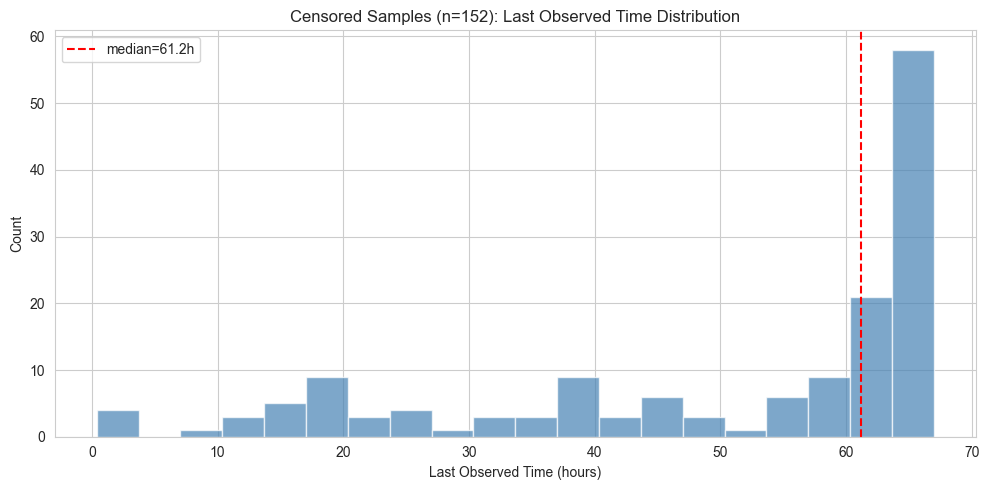

Censored time_to_hit_hours stats:
count    152.000000
mean      50.095555
std       19.402121
min        0.374486
25%       38.175209
50%       61.168905
75%       65.113659
max       66.994474
Name: time_to_hit_hours, dtype: float64


In [18]:
# Censored samples: last observed time distribution
censored = train[train['event'] == 0]
hit = train[train['event'] == 1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(censored['time_to_hit_hours'], bins=20, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(censored['time_to_hit_hours'].median(), color='red', linestyle='--',
           label=f'median={censored["time_to_hit_hours"].median():.1f}h')
ax.set_xlabel('Last Observed Time (hours)')
ax.set_ylabel('Count')
ax.set_title(f'Censored Samples (n={len(censored)}): Last Observed Time Distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Censored time_to_hit_hours stats:')
print(censored['time_to_hit_hours'].describe())

In [19]:
# Informative censoring check: are censored samples systematically different?
# Compare feature means between event=1 and event=0 using t-test
rows = []
for feat in feature_cols:
    hit_vals = hit[feat].dropna()
    cens_vals = censored[feat].dropna()
    if hit_vals.std() == 0 and cens_vals.std() == 0:
        t_stat, p_val = 0, 1.0
    else:
        t_stat, p_val = stats.ttest_ind(hit_vals, cens_vals, equal_var=False)
    rows.append({
        'feature': feat,
        'mean_hit': hit_vals.mean(),
        'mean_censored': cens_vals.mean(),
        'diff': hit_vals.mean() - cens_vals.mean(),
        't_stat': t_stat,
        'p_value': p_val
    })

inform_df = pd.DataFrame(rows).sort_values('p_value')
print('=== Informative Censoring: Feature Differences (event=1 vs event=0) ===')
print('Features with p < 0.05 (sorted by significance):')
sig = inform_df[inform_df['p_value'] < 0.05]
print(sig[['feature', 'mean_hit', 'mean_censored', 'diff', 'p_value']].round(4).to_string(index=False))
print(f'\n{len(sig)} / {len(feature_cols)} features show significant difference')

=== Informative Censoring: Feature Differences (event=1 vs event=0) ===
Features with p < 0.05 (sorted by significance):
                     feature  mean_hit  mean_censored         diff  p_value
            dist_min_ci_0_5h 2285.8183    179832.3031 -177546.4847   0.0000
low_temporal_resolution_0_5h    0.4783         0.8421      -0.3638   0.0000
          dt_first_last_0_5h    1.8883         0.5675       1.3208   0.0000
               alignment_abs    0.3429         0.0954       0.2475   0.0000
         num_perimeters_0_5h    3.4783         1.4211       2.0572   0.0000
               area_first_ha  230.3747       795.6068    -565.2321   0.0002
          spread_bearing_cos    0.7220         0.9669      -0.2449   0.0003
                log1p_growth    0.9703         0.1256       0.8447   0.0011
          spread_bearing_deg   33.2069         4.9494      28.2575   0.0013
            log1p_area_first    4.1652         4.9185      -0.7533   0.0069
         log_area_ratio_0_5h    0.1674     

In [20]:
# Horizon eligible samples and positive rate summary table
print('=== Horizon Eligible Samples Summary ===')
print(horizon_df.to_string(index=False))
print()
print('Key observations:')
print('- As horizon increases, more hit samples become eligible (label=1 grows)')
print('- As horizon increases, more censored samples get excluded')
print('  (their last_observed_time falls within the horizon)')
print('- At 72h, most censored samples are excluded, leaving mostly hits')
print('  -> predicting prob_72h close to 1.0 is a reasonable strategy')

=== Horizon Eligible Samples Summary ===
horizon  label=1 (hit)  label=0 (survive)  excluded (censored)  eligible_total positive_rate
    12h             49                146                    6             195         25.1%
    24h             63                127                   25             190         33.2%
    48h             66                 97                   55             163         40.5%
    72h             69                  0                  152              69        100.0%

Key observations:
- As horizon increases, more hit samples become eligible (label=1 grows)
- As horizon increases, more censored samples get excluded
  (their last_observed_time falls within the horizon)
- At 72h, most censored samples are excluded, leaving mostly hits
  -> predicting prob_72h close to 1.0 is a reasonable strategy


## Section 8: Key Findings Summary

### Data Overview
- 221 training samples, 95 test samples, 34 features
- 69 hits (event=1, 31%) + 152 censored (event=0, 69%)
- No missing values in either dataset

### Target Variable
- time_to_hit_hours ranges from 0 to 72 hours
- Hit events (event=1) tend to cluster at shorter times
- Censored samples have variable last-observed times (NOT all at 72h)

### Horizon Analysis
- 72h horizon: nearly all eligible samples are positive -> predict prob_72h close to 1.0
- 12h horizon: most balanced, critical for C-index optimization
- Censored samples with short observation windows get excluded at each horizon

### Key Features
- **dist_min_ci_0_5h**: strongest predictor - closer fires are more likely to hit
- **closing_speed_m_per_h**: positive closing speed indicates approaching fire
- **area_first_ha**: larger initial fires show different hit patterns
- Many growth/kinematics features are zero when low_temporal_resolution=1

### Feature Engineering Notes
- High collinearity exists between related features (growth variants, speed variants)
- low_temporal_resolution=1 samples have all-zero growth/motion features
- Consider log-transforming dist_min_ci_0_5h and area_first_ha

### Censoring Pattern
- Censoring is NOT random (informative censoring confirmed)
- Censored and hit samples differ systematically on key features
- Survival models must properly account for censoring mechanism

### Modeling Implications
1. Use survival-aware models (Cox PH, RSF, or gradient boosting with survival loss)
2. Focus on prob_12h optimization for C-index
3. Consider prob_72h = 1.0 as a strong baseline
4. Handle collinear features (drop or regularize)
5. Small dataset -> strong regularization + careful CV strategy needed
6. Monotonicity constraint: prob_12h <= prob_24h <= prob_48h <= prob_72h